# Gefangenschafts-Index (Quaternionen)

Dieses Notebook berechnet einen einfachen numerischen Index der raumzeitlichen Bindung auf Basis des Imaginärteils eines Quaternionen.

In [29]:
from sage.all import QuaternionAlgebra, QQ, RR

# Definition der Algebra
Q = QuaternionAlgebra(QQ, -1, -1)

In [30]:
def fmt_index(x):
    if x == 0:
        return "0.00"
    elif x < 1e-4:
        return f"{x:.2e}"
    else:
        return f"{x:.2f}"


def berechne_gefangenschafts_index(quaternion_koeffizienten):
    """
    Berechnet den numerischen Index der raumzeitlichen Bindung.
    Ein Index von 0 bedeutet absolute Freiheit (Photon).
    """
    q = Q(quaternion_koeffizienten)
    # Norm des Imaginärteils als Maß für die Kettenstärke
    imag_norm = float(RR(q[1]^2 + q[2]^2 + q[3]^2))

    if imag_norm == 0:
        return f"Freiheit (Photon) - Index: {fmt_index(imag_norm)}"
    elif imag_norm < 1e-4:
        return f"Schattenzustand (Neutrino-artig) - Index: {fmt_index(imag_norm)}"
    elif imag_norm < 1.0:
        return f"Leicht gebunden - Index: {fmt_index(imag_norm)}"
    else:
        return f"Schwere Kette / stark gebunden - Index: {fmt_index(imag_norm)}"

In [31]:
# Test der visuellen Zustände aus der Grafik
print(berechne_gefangenschafts_index((1, 0, 0, 0)))          # Photon
print(berechne_gefangenschafts_index((1, 0.00005, 0, 0)))    # Neutrino
print(berechne_gefangenschafts_index((1, 0.5, 0.2, 0.1)))    # Elektron
print(berechne_gefangenschafts_index((1, 2.0, -1.5, 3.0)))   # Quark

Freiheit (Photon) - Index: 0.00
Schattenzustand (Neutrino-artig) - Index: 2.50e-09
Leicht gebunden - Index: 0.30
Schwere Kette / stark gebunden - Index: 15.25


In [32]:
# Erweiterte Testtabelle
beispiele = [
    ("Photon", (1, 0, 0, 0)),
    ("Neutrino", (1, 0.00005, 0, 0)),
    ("Elektron", (1, 0.5, 0.2, 0.1)),
    ("Quark", (1, 2.0, -1.5, 3.0)),
    ("Zwischenzustand", (1, 0.2, 0.2, 0.2)),
]

def format_quaternion(q):
    return f"({q[0]:.2f}, {q[1]:.2f}, {q[2]:.2f}, {q[3]:.2f})"

print("Zustand".ljust(16), "Quaternion".ljust(28), "Klassifikation")
print("-" * 90)
for name, q in beispiele:
    klassifikation = berechne_gefangenschafts_index(q)
    print(name.ljust(16), format_quaternion(q).ljust(28), klassifikation)

Zustand          Quaternion                   Klassifikation
------------------------------------------------------------------------------------------
Photon           (1.00, 0.00, 0.00, 0.00)     Freiheit (Photon) - Index: 0.00
Neutrino         (1.00, 0.00, 0.00, 0.00)     Schattenzustand (Neutrino-artig) - Index: 2.50e-09
Elektron         (1.00, 0.50, 0.20, 0.10)     Leicht gebunden - Index: 0.30
Quark            (1.00, 2.00, -1.50, 3.00)    Schwere Kette / stark gebunden - Index: 15.25
Zwischenzustand  (1.00, 0.20, 0.20, 0.20)     Leicht gebunden - Index: 0.12


In [33]:
# Energieskala: diskret (Stufen) und kontinuierlich (Radius/Log/Anregungsdichte)
from math import sqrt, log1p

def berechne_index_wert(quaternion_koeffizienten):
    q = Q(quaternion_koeffizienten)
    return float(RR(q[1]^2 + q[2]^2 + q[3]^2))

def berechne_anregungsdichte(quaternion_koeffizienten):
    a, b, c, d = quaternion_koeffizienten
    index = b**2 + c**2 + d**2
    gesamt = a**2 + index
    return 0.0 if gesamt == 0 else index / gesamt

def energiestufe(index):
    if index < 1.0:
        return "leicht"
    elif index < 10.0:
        return "mittel"
    elif index < 50.0:
        return "hoch"
    else:
        return "extrem"

energie_beispiele = [
    ("Leicht", (1, 0.6, 0.4, 0.1)),
    ("Mittel", (1, 1.5, 1.0, 1.2)),
    ("Hoch", (1, 4.0, 3.0, 4.0)),
    ("Extrem", (1, 8.0, 6.0, 2.0)),
]

print(
    "Kategorie".ljust(10),
    "Quaternion".ljust(28),
    "Index I".ljust(9),
    "Radius r".ljust(10),
    "log(1+I)".ljust(10),
    "E_norm".ljust(8),
    "Stufe",
)
print("-" * 95)
for name, q in energie_beispiele:
    index = berechne_index_wert(q)
    radius = sqrt(index)
    energie_log = log1p(index)
    e_norm = berechne_anregungsdichte(q)
    print(
        name.ljust(10),
        format_quaternion(q).ljust(28),
        f"{index:.2f}".ljust(9),
        f"{radius:.2f}".ljust(10),
        f"{energie_log:.2f}".ljust(10),
        f"{e_norm:.3f}".ljust(8),
        energiestufe(index),
    )

Kategorie  Quaternion                   Index I   Radius r   log(1+I)   E_norm   Stufe
-----------------------------------------------------------------------------------------------
Leicht     (1.00, 0.60, 0.40, 0.10)     0.53      0.73       0.43       0.346    leicht
Mittel     (1.00, 1.50, 1.00, 1.20)     4.69      2.17       1.74       0.824    mittel
Hoch       (1.00, 4.00, 3.00, 4.00)     41.00     6.40       3.74       0.976    hoch
Extrem     (1.00, 8.00, 6.00, 2.00)     104.00    10.20      4.65       0.990    extrem


In [34]:
# Erste 10 Atome: Schalenverteilung und Valenzdaten

# Achtung:
# Diese Funktion verwendet idealisierte Bohr-Schalenkapazitaeten 2n^2.
# Fuer H bis Ne ist das als Valenzmodell brauchbar.
# Fuer schwere Elemente ist es ein Huellen-/Bindungsmodell,
# aber keine realistische chemische Orbitalbeschreibung.
def verteile_elektronen_auf_schalen(ordnungzahl):
    kapazitaeten = [2, 8, 18, 32, 50, 72]
    rest = ordnungzahl
    schalen = []
    for cap in kapazitaeten:
        if rest <= 0:
            break
        belegung = min(rest, cap)
        schalen.append(belegung)
        rest -= belegung
    return schalen


atome_1_bis_10 = [
    (1, "H", "Wasserstoff"),
    (2, "He", "Helium"),
    (3, "Li", "Lithium"),
    (4, "Be", "Beryllium"),
    (5, "B", "Bor"),
    (6, "C", "Kohlenstoff"),
    (7, "N", "Stickstoff"),
    (8, "O", "Sauerstoff"),
    (9, "F", "Fluor"),
    (10, "Ne", "Neon"),
]

schalen_namen = ["K", "L", "M", "N", "O", "P"]

print(
    "Z".ljust(4),
    "Atom".ljust(6),
    "Name".ljust(13),
    "Schalen".ljust(20),
    "Valenzschale".ljust(14),
    "Valenze-",
)
print(" " * 57 + "lektronen")
print("-" * 75)

for z, symbol, name in atome_1_bis_10:
    schalen = verteile_elektronen_auf_schalen(z)
    valenz_elektronen = schalen[-1]
    n_valenz = len(schalen)
    valenzschale_name = schalen_namen[n_valenz - 1]
    schalen_text = ", ".join(f"{schalen_namen[i]}:{e}" for i, e in enumerate(schalen))

    print(
        str(z).ljust(4),
        symbol.ljust(6),
        name.ljust(13),
        schalen_text.ljust(20),
        f"n={n_valenz} ({valenzschale_name})".ljust(14),
        str(valenz_elektronen),
    )

Z    Atom   Name          Schalen              Valenzschale   Valenze-
                                                         lektronen
---------------------------------------------------------------------------
1    H      Wasserstoff   K:1                  n=1 (K)        1
2    He     Helium        K:2                  n=1 (K)        2
3    Li     Lithium       K:2, L:1             n=2 (L)        1
4    Be     Beryllium     K:2, L:2             n=2 (L)        2
5    B      Bor           K:2, L:3             n=2 (L)        3
6    C      Kohlenstoff   K:2, L:4             n=2 (L)        4
7    N      Stickstoff    K:2, L:5             n=2 (L)        5
8    O      Sauerstoff    K:2, L:6             n=2 (L)        6
9    F      Fluor         K:2, L:7             n=2 (L)        7
10   Ne     Neon          K:2, L:8             n=2 (L)        8


In [35]:
# Erste 10 Atome: chemische Einordnung (Gruppe/Familie) und typische Valenz

chemie_info = {
    "H": {"familie": "Nichtmetall", "gruppe": 1, "typische_valenz": "+1 (auch -1 in Hydriden)"},
    "He": {"familie": "Edelgas", "gruppe": 18, "typische_valenz": "0"},
    "Li": {"familie": "Alkalimetall", "gruppe": 1, "typische_valenz": "+1"},
    "Be": {"familie": "Erdalkalimetall", "gruppe": 2, "typische_valenz": "+2"},
    "B": {"familie": "Borgruppe", "gruppe": 13, "typische_valenz": "+3"},
    "C": {"familie": "Kohlenstoffgruppe", "gruppe": 14, "typische_valenz": "-4, +2, +4"},
    "N": {"familie": "Pnictogene", "gruppe": 15, "typische_valenz": "-3, +3, +5"},
    "O": {"familie": "Chalkogene", "gruppe": 16, "typische_valenz": "-2"},
    "F": {"familie": "Halogen", "gruppe": 17, "typische_valenz": "-1"},
    "Ne": {"familie": "Edelgas", "gruppe": 18, "typische_valenz": "0"},
}

print(
    "Z".ljust(4),
    "Atom".ljust(6),
    "Familie".ljust(20),
    "Gruppe".ljust(8),
    "Typische Valenz/Oxidationszahl",
)
print("-" * 90)

for z, symbol, name in atome_1_bis_10:
    info = chemie_info[symbol]
    print(
        str(z).ljust(4),
        symbol.ljust(6),
        info["familie"].ljust(20),
        str(info["gruppe"]).ljust(8),
        info["typische_valenz"],
    )

Z    Atom   Familie              Gruppe   Typische Valenz/Oxidationszahl
------------------------------------------------------------------------------------------
1    H      Nichtmetall          1        +1 (auch -1 in Hydriden)
2    He     Edelgas              18       0
3    Li     Alkalimetall         1        +1
4    Be     Erdalkalimetall      2        +2
5    B      Borgruppe            13       +3
6    C      Kohlenstoffgruppe    14       -4, +2, +4
7    N      Pnictogene           15       -3, +3, +5
8    O      Chalkogene           16       -2
9    F      Halogen              17       -1
10   Ne     Edelgas              18       0


In [36]:
# Brücke: chemische Freiheitsgrade (Valenz) vs. innere Bindung
# plus modellhafte Quaternion-Zuordnung pro Atom

def atomarer_bindungsindex(z, valenz_elektronen):
    schalen = verteile_elektronen_auf_schalen(z)
    volle_innere_elektronen = sum(schalen[:-1])
    zf = float(z)
    valenzfreiheit = float(valenz_elektronen) / zf
    innenbindung = float(volle_innere_elektronen) / zf
    return valenzfreiheit, innenbindung


def valenz_besetzung_normiert(valenz_elektronen, n_valenz):
    kapazitaet_valenzschale = float(2 * (n_valenz ** 2))
    return float(valenz_elektronen) / kapazitaet_valenzschale


def reaktivitaetsluecke(rho_valenz):
    # Hoher Wert => offene Schale, niedriger Wert => geschlossene Schale
    return 1.0 - rho_valenz


def atom_quaternion(z, valenz_elektronen, n_valenz):
    # Modellabbildung:
    # a = 1.0 (skalare Referenz),
    # b = F_valenz, c = B_innen,
    # d = normierte Besetzung der Valenzschale (0..1)
    f_valenz, b_innen = atomarer_bindungsindex(z, valenz_elektronen)
    rho_valenz = valenz_besetzung_normiert(valenz_elektronen, n_valenz)
    return (1.0, f_valenz, b_innen, rho_valenz)


print(
    "Z".ljust(4),
    "Atom".ljust(6),
    "Bohr-e".ljust(7),
    "F_val".ljust(7),
    "B_in".ljust(7),
    "rho".ljust(7),
    "G".ljust(7),
    "q_atom".ljust(28),
    "I_atom".ljust(8),
    "E_norm",
)
print("-" * 126)

for z, symbol, name in atome_1_bis_10:
    schalen = verteile_elektronen_auf_schalen(z)
    bohr_aussen_elektronen = schalen[-1]
    n_valenz = len(schalen)
    f_valenz, b_innen = atomarer_bindungsindex(z, bohr_aussen_elektronen)
    rho_valenz = valenz_besetzung_normiert(bohr_aussen_elektronen, n_valenz)
    g_luecke = reaktivitaetsluecke(rho_valenz)

    q_atom = atom_quaternion(z, bohr_aussen_elektronen, n_valenz)
    i_atom = berechne_index_wert(q_atom)
    e_atom = berechne_anregungsdichte(q_atom)

    print(
        str(z).ljust(4),
        symbol.ljust(6),
        str(bohr_aussen_elektronen).ljust(7),
        f"{f_valenz:.2f}".ljust(7),
        f"{b_innen:.2f}".ljust(7),
        f"{rho_valenz:.2f}".ljust(7),
        f"{g_luecke:.2f}".ljust(7),
        format_quaternion(q_atom).ljust(28),
        f"{i_atom:.2f}".ljust(8),
        f"{e_atom:.3f}",
    )

Z    Atom   Bohr-e  F_val   B_in    rho     G       q_atom                       I_atom   E_norm
------------------------------------------------------------------------------------------------------------------------------
1    H      1       1.00    0.00    0.50    0.50    (1.00, 1.00, 0.00, 0.50)     1.25     0.556
2    He     2       1.00    0.00    1.00    0.00    (1.00, 1.00, 0.00, 1.00)     2.00     0.667
3    Li     1       0.33    0.67    0.12    0.88    (1.00, 0.33, 0.67, 0.12)     0.57     0.364
4    Be     2       0.50    0.50    0.25    0.75    (1.00, 0.50, 0.50, 0.25)     0.56     0.360
5    B      3       0.60    0.40    0.38    0.62    (1.00, 0.60, 0.40, 0.38)     0.66     0.398
6    C      4       0.67    0.33    0.50    0.50    (1.00, 0.67, 0.33, 0.50)     0.81     0.446
7    N      5       0.71    0.29    0.62    0.38    (1.00, 0.71, 0.29, 0.62)     0.98     0.496
8    O      6       0.75    0.25    0.75    0.25    (1.00, 0.75, 0.25, 0.75)     1.19     0.543
9    F  

In [37]:
# Erweiterte Atomtabelle bis zum ersten Transuran (Neptunium, Z=93)

elemente_bis_neptunium = [
    (1, "H", "Wasserstoff"),
    (2, "He", "Helium"),
    (3, "Li", "Lithium"),
    (4, "Be", "Beryllium"),
    (5, "B", "Bor"),
    (6, "C", "Kohlenstoff"),
    (7, "N", "Stickstoff"),
    (8, "O", "Sauerstoff"),
    (9, "F", "Fluor"),
    (10, "Ne", "Neon"),
    (11, "Na", "Natrium"),
    (12, "Mg", "Magnesium"),
    (13, "Al", "Aluminium"),
    (14, "Si", "Silicium"),
    (15, "P", "Phosphor"),
    (16, "S", "Schwefel"),
    (17, "Cl", "Chlor"),
    (18, "Ar", "Argon"),
    (19, "K", "Kalium"),
    (20, "Ca", "Calcium"),
    (21, "Sc", "Scandium"),
    (22, "Ti", "Titan"),
    (23, "V", "Vanadium"),
    (24, "Cr", "Chrom"),
    (25, "Mn", "Mangan"),
    (26, "Fe", "Eisen"),
    (27, "Co", "Kobalt"),
    (28, "Ni", "Nickel"),
    (29, "Cu", "Kupfer"),
    (30, "Zn", "Zink"),
    (31, "Ga", "Gallium"),
    (32, "Ge", "Germanium"),
    (33, "As", "Arsen"),
    (34, "Se", "Selen"),
    (35, "Br", "Brom"),
    (36, "Kr", "Krypton"),
    (37, "Rb", "Rubidium"),
    (38, "Sr", "Strontium"),
    (39, "Y", "Yttrium"),
    (40, "Zr", "Zirkonium"),
    (41, "Nb", "Niob"),
    (42, "Mo", "Molybdaen"),
    (43, "Tc", "Technetium"),
    (44, "Ru", "Ruthenium"),
    (45, "Rh", "Rhodium"),
    (46, "Pd", "Palladium"),
    (47, "Ag", "Silber"),
    (48, "Cd", "Cadmium"),
    (49, "In", "Indium"),
    (50, "Sn", "Zinn"),
    (51, "Sb", "Antimon"),
    (52, "Te", "Tellur"),
    (53, "I", "Iod"),
    (54, "Xe", "Xenon"),
    (55, "Cs", "Caesium"),
    (56, "Ba", "Barium"),
    (57, "La", "Lanthan"),
    (58, "Ce", "Cer"),
    (59, "Pr", "Praseodym"),
    (60, "Nd", "Neodym"),
    (61, "Pm", "Promethium"),
    (62, "Sm", "Samarium"),
    (63, "Eu", "Europium"),
    (64, "Gd", "Gadolinium"),
    (65, "Tb", "Terbium"),
    (66, "Dy", "Dysprosium"),
    (67, "Ho", "Holmium"),
    (68, "Er", "Erbium"),
    (69, "Tm", "Thulium"),
    (70, "Yb", "Ytterbium"),
    (71, "Lu", "Lutetium"),
    (72, "Hf", "Hafnium"),
    (73, "Ta", "Tantal"),
    (74, "W", "Wolfram"),
    (75, "Re", "Rhenium"),
    (76, "Os", "Osmium"),
    (77, "Ir", "Iridium"),
    (78, "Pt", "Platin"),
    (79, "Au", "Gold"),
    (80, "Hg", "Quecksilber"),
    (81, "Tl", "Thallium"),
    (82, "Pb", "Blei"),
    (83, "Bi", "Bismut"),
    (84, "Po", "Polonium"),
    (85, "At", "Astat"),
    (86, "Rn", "Radon"),
    (87, "Fr", "Francium"),
    (88, "Ra", "Radium"),
    (89, "Ac", "Actinium"),
    (90, "Th", "Thorium"),
    (91, "Pa", "Protactinium"),
    (92, "U", "Uran"),
    (93, "Np", "Neptunium"),
]

modelltyp = "Bohr-Huellenmodell, nicht Orbitalchemie"
print(f"Modelltyp: {modelltyp}")

print(
    "Z".ljust(4),
    "Atom".ljust(6),
    "Name".ljust(14),
    "Bohr-e".ljust(7),
    "F_val".ljust(7),
    "B_in".ljust(7),
    "rho".ljust(7),
    "G".ljust(7),
    "q_atom".ljust(28),
    "I_atom".ljust(8),
    "E_norm".ljust(8),
    "Bohr-Aussenschale",
)
print("-" * 146)

for z, symbol, name in elemente_bis_neptunium:
    schalen = verteile_elektronen_auf_schalen(z)
    bohr_aussen_elektronen = schalen[-1]
    n_valenz = len(schalen)
    valenzschale_name = schalen_namen[n_valenz - 1]

    f_valenz, b_innen = atomarer_bindungsindex(z, bohr_aussen_elektronen)
    rho_valenz = valenz_besetzung_normiert(bohr_aussen_elektronen, n_valenz)
    g_luecke = reaktivitaetsluecke(rho_valenz)
    q_atom = atom_quaternion(z, bohr_aussen_elektronen, n_valenz)
    i_atom = berechne_index_wert(q_atom)
    e_atom = berechne_anregungsdichte(q_atom)

    print(
        str(z).ljust(4),
        symbol.ljust(6),
        name.ljust(14),
        str(bohr_aussen_elektronen).ljust(7),
        f"{f_valenz:.2f}".ljust(7),
        f"{b_innen:.2f}".ljust(7),
        f"{rho_valenz:.2f}".ljust(7),
        f"{g_luecke:.2f}".ljust(7),
        format_quaternion(q_atom).ljust(28),
        f"{i_atom:.2f}".ljust(8),
        f"{e_atom:.3f}".ljust(8),
        f"n={n_valenz} ({valenzschale_name})",
    )

Modelltyp: Bohr-Huellenmodell, nicht Orbitalchemie
Z    Atom   Name           Bohr-e  F_val   B_in    rho     G       q_atom                       I_atom   E_norm   Bohr-Aussenschale
--------------------------------------------------------------------------------------------------------------------------------------------------
1    H      Wasserstoff    1       1.00    0.00    0.50    0.50    (1.00, 1.00, 0.00, 0.50)     1.25     0.556    n=1 (K)
2    He     Helium         2       1.00    0.00    1.00    0.00    (1.00, 1.00, 0.00, 1.00)     2.00     0.667    n=1 (K)
3    Li     Lithium        1       0.33    0.67    0.12    0.88    (1.00, 0.33, 0.67, 0.12)     0.57     0.364    n=2 (L)
4    Be     Beryllium      2       0.50    0.50    0.25    0.75    (1.00, 0.50, 0.50, 0.25)     0.56     0.360    n=2 (L)
5    B      Bor            3       0.60    0.40    0.38    0.62    (1.00, 0.60, 0.40, 0.38)     0.66     0.398    n=2 (L)
6    C      Kohlenstoff    4       0.67    0.33    0.50    0

In [38]:
# Nukleoid-Tabelle (modellhafte Isotopenzone)
# Hinweis:
# Dies ist KEINE experimentelle Nuklidkarte, sondern eine einfache
# Stabilitaetsabschaetzung ueber N/Z-Baender (Tal-der-Stabilitaet-Proxy).


def isotopen_zone_modell(z):
    # Leichte Kerne: N/Z ~ 1; schwere Kerne: N/Z zunehmend bis ~1.6
    ratio_ref = 1.0 + 0.005 * z
    ratio_min = max(0.95, ratio_ref - 0.08)
    ratio_max = min(1.65, ratio_ref + 0.12)

    n_ref = int(round(z * ratio_ref))
    n_min = int(round(z * ratio_min))
    n_max = int(round(z * ratio_max))

    a_ref = z + n_ref
    a_min = z + n_min
    a_max = z + n_max
    return a_min, a_ref, a_max, ratio_ref


print("Nukleoid-Zonentabelle (bohr-quaternionisches Modell)")
print(
    "Z".ljust(4),
    "Atom".ljust(6),
    "Name".ljust(14),
    "A_min".ljust(8),
    "A_ref".ljust(8),
    "A_max".ljust(8),
    "N/Z_ref".ljust(8),
    "q_atom",
)
print("-" * 92)

for z, symbol, name in elemente_bis_neptunium:
    schalen = verteile_elektronen_auf_schalen(z)
    bohr_aussen_elektronen = schalen[-1]
    n_valenz = len(schalen)
    q_atom = atom_quaternion(z, bohr_aussen_elektronen, n_valenz)

    a_min, a_ref, a_max, ratio_ref = isotopen_zone_modell(z)

    print(
        str(z).ljust(4),
        symbol.ljust(6),
        name.ljust(14),
        str(a_min).ljust(8),
        str(a_ref).ljust(8),
        str(a_max).ljust(8),
        f"{ratio_ref:.2f}".ljust(8),
        format_quaternion(q_atom),
    )

Nukleoid-Zonentabelle (bohr-quaternionisches Modell)
Z    Atom   Name           A_min    A_ref    A_max    N/Z_ref  q_atom
--------------------------------------------------------------------------------------------
1    H      Wasserstoff    2        2        2        1.00     (1.00, 1.00, 0.00, 0.50)
2    He     Helium         4        4        4        1.01     (1.00, 1.00, 0.00, 1.00)
3    Li     Lithium        6        6        6        1.02     (1.00, 0.33, 0.67, 0.12)
4    Be     Beryllium      8        8        9        1.02     (1.00, 0.50, 0.50, 0.25)
5    B      Bor            10       10       11       1.02     (1.00, 0.60, 0.40, 0.38)
6    C      Kohlenstoff    12       12       13       1.03     (1.00, 0.67, 0.33, 0.50)
7    N      Stickstoff     14       14       15       1.04     (1.00, 0.71, 0.29, 0.62)
8    O      Sauerstoff     16       16       17       1.04     (1.00, 0.75, 0.25, 0.75)
9    F      Fluor          18       18       19       1.04     (1.00, 0.78, 0.22

In [39]:
# Hybrid: Referenzisotope (H-Kr) + Modell-Fallback (Rb-Np)
# Referenzwerte: repraesentative stabile/haeufige Isotope (A_ref)
# Ab Z > 36 wird auf das N/Z-Modellband aus isotopen_zone_modell() gewechselt.

referenz_isotope_bis_kr = {
    1: 1,   2: 4,   3: 7,   4: 9,   5: 11,  6: 12,
    7: 14,  8: 16,  9: 19,  10: 20, 11: 23, 12: 24,
    13: 27, 14: 28, 15: 31, 16: 32, 17: 35, 18: 40,
    19: 39, 20: 40, 21: 45, 22: 48, 23: 51, 24: 52,
    25: 55, 26: 56, 27: 59, 28: 58, 29: 63, 30: 64,
    31: 69, 32: 74, 33: 75, 34: 80, 35: 79, 36: 84,
}


# Explizite Modellformeln fuer den Fortsetzungsbereich (Z >= 37):
# N/Z_ref(Z) = 1 + 0.005*Z
# A_ref(Z)   = Z + round(Z * N/Z_ref)
# A_min(Z)   = Z + round(Z * max(0.95, N/Z_ref - 0.08))
# A_max(Z)   = Z + round(Z * min(1.65, N/Z_ref + 0.12))
def isotopen_zone_hybrid(z):
    if z in referenz_isotope_bis_kr:
        a_ref = int(referenz_isotope_bis_kr[z])
        # Schmale Zone fuer bekannte leichte/mittlere stabile Isotope
        a_min = int(max(z, a_ref - 2))
        a_max = int(a_ref + 2)
        n_ref = int(a_ref - z)
        ratio_ref = float(n_ref) / float(z)
        quelle = "Referenz"
        return a_min, a_ref, a_max, ratio_ref, quelle

    a_min, a_ref, a_max, ratio_ref = isotopen_zone_modell(z)
    quelle = "Modell"
    return int(a_min), int(a_ref), int(a_max), float(ratio_ref), quelle


def kern_instabilitaet(z, a_ref):
    n = int(a_ref - z)
    neutronen_ueberschuss = int(n - z)  # Delta_N = N - Z
    coulomb_last = float((z ** 2) / a_ref) if a_ref > 0 else 0.0  # C = Z^2 / A
    return neutronen_ueberschuss, coulomb_last


print("Nukleoid-Tabelle (hybrid: Referenz H-Kr, Modell ab Rb)")
print("Formeln Modellbereich: N/Z_ref=1+0.005*Z; A_ref=Z+round(Z*N/Z_ref)")
print(
    "Z".ljust(4),
    "Atom".ljust(6),
    "Name".ljust(14),
    "A_min".ljust(8),
    "A_ref".ljust(8),
    "A_max".ljust(8),
    "W_A".ljust(7),
    "N/Z_ref".ljust(8),
    "DeltaA".ljust(8),
    "Delta_N".ljust(9),
    "C=Z^2/A".ljust(10),
    "Quelle".ljust(10),
    "q_atom",
)
print("-" * 146)

for z, symbol, name in elemente_bis_neptunium:
    schalen = verteile_elektronen_auf_schalen(z)
    bohr_aussen_elektronen = schalen[-1]
    n_valenz = len(schalen)
    q_atom = atom_quaternion(z, bohr_aussen_elektronen, n_valenz)

    a_min, a_ref, a_max, ratio_ref, quelle = isotopen_zone_hybrid(z)
    _, a_ref_modell, _, _ = isotopen_zone_modell(z)
    w_a = int(a_max - a_min)
    delta_n, coulomb = kern_instabilitaet(z, a_ref)

    if quelle == "Referenz":
        delta_a = int(abs(int(a_ref) - int(a_ref_modell)))
        delta_a_text = str(delta_a)
    else:
        delta_a_text = "-"

    print(
        str(z).ljust(4),
        symbol.ljust(6),
        name.ljust(14),
        str(a_min).ljust(8),
        str(a_ref).ljust(8),
        str(a_max).ljust(8),
        str(w_a).ljust(7),
        f"{ratio_ref:.2f}".ljust(8),
        delta_a_text.ljust(8),
        str(delta_n).ljust(9),
        f"{coulomb:.2f}".ljust(10),
        quelle.ljust(10),
        format_quaternion(q_atom),
    )

Nukleoid-Tabelle (hybrid: Referenz H-Kr, Modell ab Rb)
Formeln Modellbereich: N/Z_ref=1+0.005*Z; A_ref=Z+round(Z*N/Z_ref)
Z    Atom   Name           A_min    A_ref    A_max    W_A     N/Z_ref  DeltaA   Delta_N   C=Z^2/A    Quelle     q_atom
--------------------------------------------------------------------------------------------------------------------------------------------------
1    H      Wasserstoff    1        1        3        2       0.00     1        -1        1.00       Referenz   (1.00, 1.00, 0.00, 0.50)
2    He     Helium         2        4        6        4       1.00     0        0         1.00       Referenz   (1.00, 1.00, 0.00, 1.00)
3    Li     Lithium        5        7        9        4       1.33     1        1         1.29       Referenz   (1.00, 0.33, 0.67, 0.12)
4    Be     Beryllium      7        9        11       4       1.25     1        1         1.78       Referenz   (1.00, 0.50, 0.50, 0.25)
5    B      Bor            9        11       13       4       1.

In [40]:
# Realteil-Studie: konstantes I, variable Skalardominanz a=E
# Ziel: absolute Bindung I bleibt gleich, relative Bindung R sinkt bei wachsendem a.


def relative_bindung(a, b, c, d):
    i_abs = float(b**2 + c**2 + d**2)
    r_rel = float(i_abs / (a**2 + i_abs)) if (a**2 + i_abs) > 0 else 0.0
    return i_abs, r_rel


b, c, d = 4.0, 3.0, 4.0
a_werte = [0.5, 1.0, 2.0, 5.0, 10.0, 20.0]

print("Realteil-Studie fuer q=(a,4,3,4)")
print(
    "a=E".ljust(8),
    "q".ljust(28),
    "I=b^2+c^2+d^2".ljust(16),
    "|q|".ljust(10),
    "R=I/(a^2+I)".ljust(14),
    "E_norm",
)
print("-" * 92)

for a in a_werte:
    q = (a, b, c, d)
    i_abs, r_rel = relative_bindung(a, b, c, d)
    q_betrag = float((a**2 + i_abs) ** 0.5)
    e_norm = berechne_anregungsdichte(q)

    print(
        f"{a:.2f}".ljust(8),
        format_quaternion(q).ljust(28),
        f"{i_abs:.2f}".ljust(16),
        f"{q_betrag:.2f}".ljust(10),
        f"{r_rel:.3f}".ljust(14),
        f"{e_norm:.3f}",
    )

Realteil-Studie fuer q=(a,4,3,4)
a=E      q                            I=b^2+c^2+d^2    |q|        R=I/(a^2+I)    E_norm
--------------------------------------------------------------------------------------------
0.50     (0.50, 4.00, 3.00, 4.00)     41.00            6.42       0.994          0.994
1.00     (1.00, 4.00, 3.00, 4.00)     41.00            6.48       0.976          0.976
2.00     (2.00, 4.00, 3.00, 4.00)     41.00            6.71       0.911          0.911
5.00     (5.00, 4.00, 3.00, 4.00)     41.00            8.12       0.621          0.621
10.00    (10.00, 4.00, 3.00, 4.00)    41.00            11.87      0.291          0.291
20.00    (20.00, 4.00, 3.00, 4.00)    41.00            21.00      0.093          0.093


Konsistenzcheck max|R-E_norm| = 0.000e-12


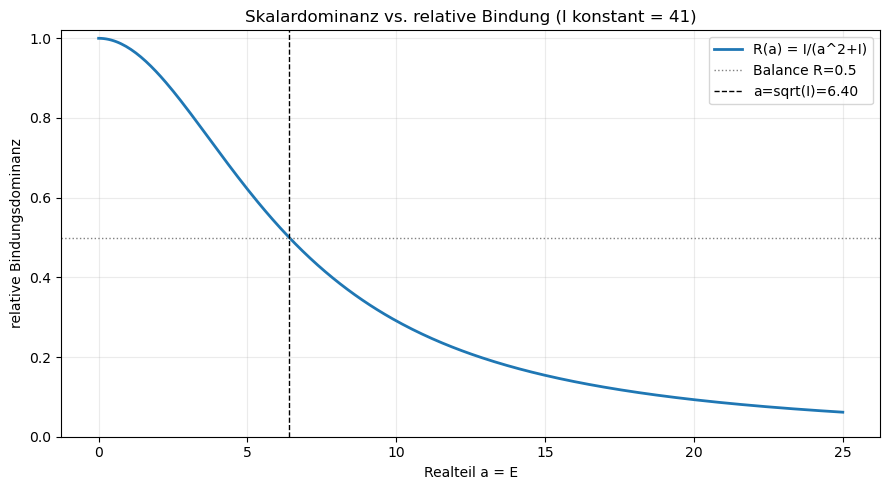

In [41]:
# Visualisierung: relative Bindung R(a) bei konstantem I
# Hinweis: E_norm(a) ist hier identisch zu R(a) und wird als Konsistenzcheck ausgegeben.
import matplotlib.pyplot as plt

def linspace(start, stop, n):
    if n <= 1:
        return [start]
    step = (stop - start) / (n - 1)
    return [start + i * step for i in range(n)]

b, c, d = 4.0, 3.0, 4.0
i_abs = b**2 + c**2 + d**2

a_werte_plot = linspace(0.0, 25.0, 300)
r_werte = []
e_norm_werte = []

for a in a_werte_plot:
    r = i_abs / (a**2 + i_abs) if (a**2 + i_abs) > 0 else 0.0
    q = (a, b, c, d)
    e_norm = berechne_anregungsdichte(q)
    r_werte.append(r)
    e_norm_werte.append(e_norm)

max_diff = max(abs(r - e) for r, e in zip(r_werte, e_norm_werte))
print(f"Konsistenzcheck max|R-E_norm| = {max_diff:.3e}")

plt.figure(figsize=(9, 5))
plt.plot(a_werte_plot, r_werte, label="R(a) = I/(a^2+I)", linewidth=2)
plt.axhline(0.5, color="gray", linestyle=":", linewidth=1, label="Balance R=0.5")
plt.axvline(i_abs**0.5, color="black", linestyle="--", linewidth=1, label=f"a=sqrt(I)={i_abs**0.5:.2f}")
plt.title("Skalardominanz vs. relative Bindung (I konstant = 41)")
plt.xlabel("Realteil a = E")
plt.ylabel("relative Bindungsdominanz")
plt.ylim(0, 1.02)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [42]:
# Orbitalbasiertes Modul: Elektronenkonfiguration (s,p,d,f) -> Quaternionachsen
# Ziel: Bohr-Huellenmodell ergaenzen durch orbitalnaehere Konfigurationen.
# Upgrade:
# 1) Ausnahmen als Elektronenverschiebung (nicht harte Ueberschreibung)
# 2) getrennte Signaturen q_orb_global und q_orb_valenz

from collections import defaultdict

# Madelung-/Aufbau-Reihenfolge bis 7p (reicht fuer Z <= 93)
ORBITAL_ORDER = [
    "1s", "2s", "2p", "3s", "3p", "4s", "3d", "4p", "5s", "4d", "5p",
    "6s", "4f", "5d", "6p", "7s", "5f", "6d", "7p"
]

CAPACITY = {"s": 2, "p": 6, "d": 10, "f": 14}

# Ausnahmen als Delta-Verschiebung: (von, nach, anzahl)
EXCEPTION_SHIFTS = {
    24: [("4s", "3d", 1)],  # Cr: 4s2 3d4 -> 4s1 3d5
    29: [("4s", "3d", 1)],  # Cu: 4s2 3d9 -> 4s1 3d10
    41: [("5s", "4d", 1)],  # Nb
    42: [("5s", "4d", 1)],  # Mo
    44: [("5s", "4d", 1)],  # Ru
    45: [("5s", "4d", 1)],  # Rh
    46: [("5s", "4d", 2)],  # Pd
    47: [("5s", "4d", 1)],  # Ag
    57: [("4f", "5d", 1)],  # La
    58: [("4f", "5d", 1)],  # Ce
    64: [("4f", "5d", 1)],  # Gd
    78: [("6s", "5d", 1)],  # Pt
    79: [("6s", "5d", 1)],  # Au
    89: [("5f", "6d", 1)],  # Ac
    90: [("5f", "6d", 2)],  # Th
    91: [("5f", "6d", 1)],  # Pa
    92: [("5f", "6d", 1)],  # U
    93: [("5f", "6d", 1)],  # Np
}


def fill_aufbau(z):
    occ = defaultdict(int)
    rest = int(z)
    for orb in ORBITAL_ORDER:
        if rest <= 0:
            break
        cap = CAPACITY[orb[-1]]
        n_add = min(rest, cap)
        occ[orb] += n_add
        rest -= n_add
    return occ


def apply_exception_shift(z, occ):
    if z not in EXCEPTION_SHIFTS:
        return occ, "Aufbau"

    corrected = defaultdict(int, occ)
    for src, dst, n_move in EXCEPTION_SHIFTS[z]:
        move_possible = min(
            int(n_move),
            corrected[src],
            CAPACITY[dst[-1]] - corrected[dst]
        )
        if move_possible > 0:
            corrected[src] -= move_possible
            corrected[dst] += move_possible

    return corrected, "Aufbau+Shift"


def configuration_string(occ):
    parts = []
    subshell_rank = {"s": 0, "p": 1, "d": 2, "f": 3}
    orbitals_sorted = sorted(
        [o for o in ORBITAL_ORDER if occ[o] > 0],
        key=lambda o: (int(o[:-1]), subshell_rank[o[-1]])
    )
    for orb in orbitals_sorted:
        parts.append(f"{orb}^{occ[orb]}")
    return " ".join(parts)


def orbital_counts(occ):
    e_s = e_p = e_d = e_f = 0
    for orb, n_e in occ.items():
        l = orb[-1]
        if l == "s":
            e_s += n_e
        elif l == "p":
            e_p += n_e
        elif l == "d":
            e_d += n_e
        elif l == "f":
            e_f += n_e
    return e_s, e_p, e_d, e_f


def valence_occ(occ):
    # Chemienahe aktive Orbitale (heuristisch):
    # - hoechste n-Schale (ns/np),
    # - partiell belegte (n-1)d,
    # - partiell belegte (n-2)f.
    n_active = [int(o[:-1]) for o in ORBITAL_ORDER if occ[o] > 0]
    if not n_active:
        return defaultdict(int)

    n_max = max(n_active)
    val = defaultdict(int)

    for orb in ORBITAL_ORDER:
        n = int(orb[:-1])
        l = orb[-1]
        e = occ[orb]
        if e == 0:
            continue

        include = False
        if n == n_max:
            include = True
        elif l == "d" and n == n_max - 1:
            include = True
        elif l == "f" and n == n_max - 2:
            include = True

        if include:
            val[orb] = e

    return val


def quaternion_from_orbitals_norm(occ, norm=None):
    # Quaternionabbildung:
    # a = 1.0 (Referenz), b = s-Anteil, c = p-Anteil, d = (d+f)-Anteil
    e_s, e_p, e_d, e_f = orbital_counts(occ)
    total = (e_s + e_p + e_d + e_f) if norm is None else float(norm)

    if total == 0:
        return (1.0, 0.0, 0.0, 0.0), (0.0, 0.0, 0.0, 0.0)

    q = (1.0, e_s / total, e_p / total, (e_d + e_f) / total)
    okto_proxy = (e_s / total, e_p / total, e_d / total, e_f / total)
    return q, okto_proxy


print("Orbitaltabelle (H bis Np): global + valenz, quaternionische Achsen")
print(
    "Z".ljust(4),
    "Atom".ljust(6),
    "Konfiguration".ljust(40),
    "q_global".ljust(28),
    "q_valenz".ljust(28),
    "Quelle",
)
print("-" * 142)

for z, symbol, name in elemente_bis_neptunium:
    occ = fill_aufbau(z)
    occ, quelle = apply_exception_shift(z, occ)

    konf = configuration_string(occ)

    q_global, _ = quaternion_from_orbitals_norm(occ, norm=z)

    occ_val = valence_occ(occ)
    q_val, _ = quaternion_from_orbitals_norm(occ_val)

    print(
        str(z).ljust(4),
        symbol.ljust(6),
        konf.ljust(40),
        format_quaternion(q_global).ljust(28),
        format_quaternion(q_val).ljust(28),
        quelle,
    )

Orbitaltabelle (H bis Np): global + valenz, quaternionische Achsen
Z    Atom   Konfiguration                            q_global                     q_valenz                     Quelle
----------------------------------------------------------------------------------------------------------------------------------------------


TypeError: unsupported format string passed to sage.rings.rational.Rational.__format__

In [ ]:
# Rydberg-Grenze im Quaternionenmodell
# Idee: gebundener Grenzzustand mit verschwindendem imaginarem Bindungsanteil.
# I(n) = 1/n^2, q_rydberg(n) = (1, 1/n, 0, 0), daher I -> 0+ fuer n -> unendlich.
# Hinweis: E_norm = I/(1+I) ist nicht exakt I, aber asymptotisch E_norm ~ I fuer grosse n.


def rydberg_index(n):
    n = float(n)
    return 1.0 / (n ** 2)


def rydberg_quaternion(n):
    n = float(n)
    epsilon = 1.0 / n
    return (1.0, epsilon, 0.0, 0.0)


def klassifikation_rydberg(i_val):
    if i_val == 0:
        return "Freiheit"
    elif i_val < 1e-4:
        return "Rydberg-Grenze / Schattenrand"
    elif i_val < 1e-2:
        return "sehr schwach gebunden"
    elif i_val < 1.0:
        return "schwach gebunden"
    else:
        return "gebunden"


n_werte = [1, 2, 3, 5, 10, 20, 50, 100, 500, 1000]

print("Rydberg-Tabelle: Grenzuebergang I -> 0+")
print(
    "n".ljust(8),
    "q_rydberg".ljust(28),
    "I(n)=1/n^2".ljust(14),
    "E_norm".ljust(12),
    "E_norm-I".ljust(12),
    "E_norm/I".ljust(12),
    "Zustand",
)
print("-" * 122)

for n in n_werte:
    q = rydberg_quaternion(n)
    i_val = rydberg_index(n)
    e_norm = berechne_anregungsdichte(q)
    delta = e_norm - i_val
    ratio = (e_norm / i_val) if i_val != 0 else 0.0
    zustand = klassifikation_rydberg(i_val)

    print(
        str(n).ljust(8),
        format_quaternion(q).ljust(28),
        f"{i_val:.3e}".ljust(14),
        f"{e_norm:.3e}".ljust(12),
        f"{delta:.3e}".ljust(12),
        f"{ratio:.6f}".ljust(12),
        zustand,
    )

print("\nGrenzsatz: lim_{n->inf} I(n) = 0+  (Rydberg-Grenzflaeche zwischen Bindung und Freiheit)")
print("Asymptotik: E_norm = I/(1+I) ~ I fuer I -> 0+")

In [ ]:
# Gefangenschafts-Skala als Grenzklassen: Photon <-> Rydberg <-> atomar <-> stark gebunden <-> BH-Limes
# Idee: Schwarzes Loch als Singularitaetsklasse I -> unendlich (nicht als Element).


def fluchtfreiheit(a, i_val):
    denom = a**2 + i_val
    return (a**2 / denom) if denom > 0 else 0.0


def zustandsklasse(i_val, e_norm):
    if i_val == 0:
        return "Photon/Freiheit"
    if i_val < 1e-4:
        return "Rydberg-Grenze"
    if i_val < 1.0:
        return "schwach gebunden"
    if i_val < 1e3:
        return "stark gebunden"
    if e_norm > 0.999999:
        return "BH-Limes"
    return "extrem gebunden"


grenzfaelle = [
    ("Photon", (1.0, 0.0, 0.0, 0.0)),
    ("Rydberg n=1000", rydberg_quaternion(1000)),
    ("Atomar Beispiel", (1.0, 0.5, 0.2, 0.1)),
    ("Quarkartig", (1.0, 2.0, -1.5, 3.0)),
    ("BH-Limes (modell)", (1.0, 1e6, 1e6, 1e6)),
]

print("Grenzklassen-Tabelle der Gefangenschaft")
print(
    "Fall".ljust(18),
    "q".ljust(34),
    "I".ljust(14),
    "E_norm".ljust(12),
    "R".ljust(12),
    "F_escape".ljust(12),
    "Klasse",
)
print("-" * 128)

for label, q in grenzfaelle:
    a, b, c, d = q
    i_val = float(b**2 + c**2 + d**2)
    e_norm = berechne_anregungsdichte(q)
    r_rel = i_val / (a**2 + i_val) if (a**2 + i_val) > 0 else 0.0
    f_escape = fluchtfreiheit(a, i_val)
    klasse = zustandsklasse(i_val, e_norm)

    print(
        label.ljust(18),
        format_quaternion(q).ljust(34),
        f"{i_val:.3e}".ljust(14),
        f"{e_norm:.6f}".ljust(12),
        f"{r_rel:.6f}".ljust(12),
        f"{f_escape:.6e}".ljust(12),
        klasse,
    )

print("\nSymmetrie der Skala: Rydberg-Limes I->0+  <->  BH-Limes I->infty")

## Axiome des Gefangenschaftsmodells

Dieses Notebook verwendet ein heuristisches quaternionisches Ordnungsschema (keine vollstaendige physikalische Theorie), definiert durch:

\[
q=(a,b,c,d),\quad a\equiv E\;\text{(skalare Referenzachse)}
\]

\[
I=b^2+c^2+d^2\quad\text{(absolute Gefangenschaft / Bindungsstaerke)}
\]

\[
E_{\text{norm}}=\frac{I}{a^2+I}\quad\text{(relative Bindungsdominanz)}
\]

\[
F_{\text{escape}}=\frac{a^2}{a^2+I}\quad\text{(Fluchtfreiheit)}
\]

\[
E_{\text{norm}}+F_{\text{escape}}=1
\]

### Grenzfaelle

- **Photon/Freiheit**: \(I=0\), damit \(E_{\text{norm}}=0\), \(F_{\text{escape}}=1\)
- **Rydberg-Grenze**: \(I\to 0^+\), fast frei, aber noch gebunden
- **Gebundene atomare/chemische Zone**: kleines bis mittleres \(I>0\)
- **Stark gebundene Kern-/Quarkzone**: grosses \(I\)
- **BH-Limes (modellhaft)**: \(I\to\infty\), \(E_{\text{norm}}\to 1\), \(F_{\text{escape}}\to 0\)

### Orbitalmodul

Das orbitalnaehere Modul trennt:

- \(q_{\text{global}}\): Orbitalanteile relativ zum Gesamtatom (Normierung mit \(Z\))
- \(q_{\text{valenz}}\): Orbitalanteile relativ zur aktiven Zone (Normierung mit aktiven Elektronen)

Damit werden historische Aufbauarchitektur und chemisch aktive Gegenwart getrennt darstellbar.

### Geltungsbereich

- Das Bohr-Huellenmodul ist explizit als **Modellnahe** gekennzeichnet, nicht als Orbitalchemie.
- Die Nukleoid-Tabelle ist **hybrid** (Referenzbereich + modellhafte Fortsetzung).
- Das Gesamtschema liefert eine konsistente mathematische Skala von Freiheit bis Gefangenschaft, jedoch keinen formalen physikalischen Beweis.

## Abstract (Kurzfassung)

Wir schlagen ein heuristisches quaternionisches Ordnungsschema fuer Bindung und Gefangenschaft vor, basierend auf dem Zustand \(q=(a,b,c,d)\) mit Gefangenschaftsindex \(I=b^2+c^2+d^2\). Die relative Bindungsdominanz wird durch \(E_{\mathrm{norm}}=I/(a^2+I)\), die komplementaere Fluchtfreiheit durch \(F_{\mathrm{escape}}=a^2/(a^2+I)\) beschrieben, sodass stets \(E_{\mathrm{norm}}+F_{\mathrm{escape}}=1\) gilt. Das Modell erzeugt eine konsistente Skala zwischen den Grenzfaellen \(I=0\) (Freiheit/Photon), \(I\to 0^+\) (Rydberg-Grenze) und \(I\to\infty\) (BH-Limes als maximaler Gefangenschaftspol). Fuer atomare Anwendungen wird ein orbitalnahes Modul eingefuehrt, das globale Orbitalarchitektur und chemisch aktive Valenzstruktur durch getrennte Signaturen \(q_{\mathrm{global}}\) und \(q_{\mathrm{valenz}}\) darstellt. Die resultierende Modellgrammatik liefert eine reproduzierbare mathematische Kompression von Freiheit, Bindung und Grenzregimen, beansprucht jedoch explizit keinen formalen physikalischen Beweis.

In [ ]:
# Primzahl-Element-Tabelle: Erzeugung (Z=p) und Primfaktor-Zuordnung (p | Z)


def ist_prim(n):
    if n < 2:
        return False
    if n == 2:
        return True
    if n % 2 == 0:
        return False
    d = 3
    while d * d <= n:
        if n % d == 0:
            return False
        d += 2
    return True


symbol_by_z = {z: symbol for z, symbol, _ in elemente_bis_neptunium}
name_by_z = {z: name for z, _, name in elemente_bis_neptunium}

primzahlen = [z for z, _, _ in elemente_bis_neptunium if ist_prim(z)]

print("Primzahl-Zuordnung zu Elementen (bis Np, Z<=93)")
print(
    "Primzahl p".ljust(10),
    "Element bei Z=p".ljust(20),
    "Anzahl Vielfache".ljust(16),
    "Elemente mit p | Z",
)
print("-" * 150)

for p in primzahlen:
    vielfache_z = [z for z in range(p, 94, p)]
    vielfache_sym = [symbol_by_z[z] for z in vielfache_z]

    erzeugung = f"{symbol_by_z[p]} ({name_by_z[p]})"
    in_elementen = ", ".join(f"{sym}{z}" for sym, z in zip(vielfache_sym, vielfache_z))

    print(
        str(p).ljust(10),
        erzeugung.ljust(20),
        str(len(vielfache_z)).ljust(16),
        in_elementen,
    )

print("\nHinweis: 'Element bei Z=p' zeigt die direkte Primzahl-Erzeugung, 'p | Z' die Primfaktor-Zugehoerigkeit.")

In [ ]:
# Arithmetische Kopplung im Primfaktor-Netzwerk (Z <= 93)
# Kennzahlen:
# omega(Z): Anzahl verschiedener Primfaktoren
# Omega(Z): Anzahl Primfaktoren mit Multiplizitaet
# C_arith(Z) = Summe_{p|Z} 1/p
# C_x(Z) = Produkt_{p|Z} 1/p

import math
import matplotlib.pyplot as plt


def primfaktor_exponenten(n):
    f = {}
    x = int(n)
    d = 2
    while d * d <= x:
        while x % d == 0:
            f[d] = f.get(d, 0) + 1
            x //= d
        d = 3 if d == 2 else d + 2
    if x > 1:
        f[x] = f.get(x, 0) + 1
    return f


daten = []
for z, symbol, name in elemente_bis_neptunium:
    f = primfaktor_exponenten(z)
    primes = sorted(f.keys())

    omega = len(primes)
    Omega = sum(f.values())
    c_arith = sum(1.0 / p for p in primes) if primes else 0.0
    c_x = math.prod((1.0 / p for p in primes)) if primes else 0.0

    daten.append({
        "z": z,
        "symbol": symbol,
        "name": name,
        "faktoren": f,
        "omega": omega,
        "Omega": Omega,
        "C_arith": c_arith,
        "C_x": c_x,
    })


print("Arithmetische Kopplungstabelle (Z <= 93)")
print(
    "Z".ljust(4),
    "Atom".ljust(6),
    "Faktorisierung".ljust(24),
    "omega".ljust(7),
    "Omega".ljust(7),
    "C_arith".ljust(10),
    "C_x",
)
print("-" * 92)

for e in daten:
    z = e["z"]
    f = e["faktoren"]
    if not f:
        fakt_str = "1"
    else:
        fakt_str = " * ".join(
            f"{p}^{exp}" if exp > 1 else f"{p}"
            for p, exp in sorted(f.items())
        )

    print(
        str(z).ljust(4),
        e["symbol"].ljust(6),
        fakt_str.ljust(24),
        str(e["omega"]).ljust(7),
        str(e["Omega"]).ljust(7),
        f"{e['C_arith']:.4f}".ljust(10),
        f"{e['C_x']:.6f}",
    )


# Top-Mehrfachschnittpunkte (nur zusammengesetzte Z, also omega >= 2)
mehrfach = [e for e in daten if e["omega"] >= 2]
mehrfach_sorted = sorted(
    mehrfach,
    key=lambda e: (e["omega"], e["C_arith"], -e["z"]),
    reverse=True,
)

print("\nTop-Mehrfachschnittpunkte (nach omega, dann C_arith)")
print("Z".ljust(4), "Atom".ljust(6), "omega".ljust(7), "C_arith".ljust(10), "Faktoren")
print("-" * 64)
for e in mehrfach_sorted[:15]:
    fakt_str = " * ".join(
        f"{p}^{exp}" if exp > 1 else f"{p}"
        for p, exp in sorted(e["faktoren"].items())
    )
    print(
        str(e["z"]).ljust(4),
        e["symbol"].ljust(6),
        str(e["omega"]).ljust(7),
        f"{e['C_arith']:.4f}".ljust(10),
        fakt_str,
    )


# Plot: C_arith gegen Z
z_vals = [e["z"] for e in daten]
c_vals = [e["C_arith"] for e in daten]
omega_vals = [e["omega"] for e in daten]

plt.figure(figsize=(10, 5))
sc = plt.scatter(z_vals, c_vals, c=omega_vals, cmap="viridis", s=40)
plt.colorbar(sc, label="omega(Z)")
plt.title("Arithmetische Kopplung C_arith(Z) im Primfaktor-Netz")
plt.xlabel("Ordnungszahl Z")
plt.ylabel("C_arith = Summe(1/p) ueber p|Z")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Top-Resonanzknoten (nach R_res = omega*C_arith)
Z    Atom   omega   C_arith    R_res      Klasse
------------------------------------------------------------------------
30   Zn     3       1.0333     3.1000     Resonanzknoten
60   Nd     3       1.0333     3.1000     Resonanzknoten
90   Th     3       1.0333     3.1000     Resonanzknoten
42   Mo     3       0.9762     2.9286     Resonanzknoten
84   Po     3       0.9762     2.9286     Resonanzknoten
66   Dy     3       0.9242     2.7727     Resonanzknoten
78   Pt     3       0.9103     2.7308     Resonanzknoten
70   Yb     3       0.8429     2.5286     Resonanzknoten
6    C      2       0.8333     1.6667     Mischknoten
12   Mg     2       0.8333     1.6667     Mischknoten
18   Ar     2       0.8333     1.6667     Mischknoten
24   Cr     2       0.8333     1.6667     Mischknoten
36   Kr     2       0.8333     1.6667     Mischknoten
48   Cd     2       0.8333     1.6667     Mischknoten
54   Xe     2       0.8333     1.6667     Mischkno

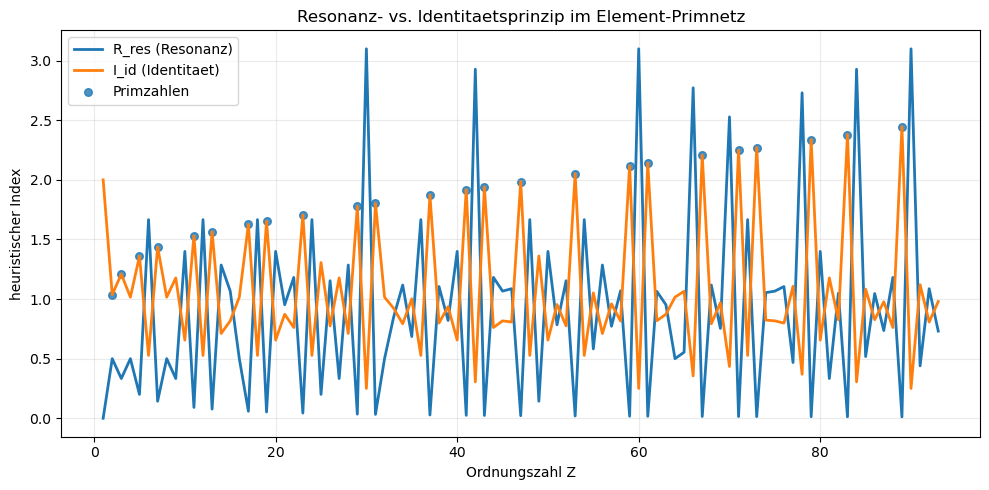

In [ ]:
# Resonanzprinzip vs. Identitaetsprinzip im Primfaktor-Netz
# Heuristische Indizes auf Basis der bereits berechneten Arithmetikdaten:
# R_res(Z)  = omega(Z) * C_arith(Z)                  (Vernetzung/Resonanz)
# I_id(Z)   = prime_bonus + (1-C_norm) + 1/(1+omega) (arithmetische Eigenstaendigkeit)
# mit prime_bonus = Z/Z_max fuer Primzahlen, sonst 0.

import matplotlib.pyplot as plt

z_max = max(e["z"] for e in daten)
c_max = max(e["C_arith"] for e in daten) if daten else 1.0

analyse = []
for e in daten:
    z = e["z"]
    omega = e["omega"]
    c = e["C_arith"]
    is_prime = ist_prim(z)

    c_norm = c / c_max if c_max > 0 else 0.0
    r_res = omega * c
    prime_bonus = (z / z_max) if is_prime else 0.0
    i_id = prime_bonus + (1.0 - c_norm) + (1.0 / (1.0 + omega))

    if omega >= 3:
        klasse = "Resonanzknoten"
    elif is_prime and z >= 47:
        klasse = "grosser Prim-Isolator"
    elif is_prime:
        klasse = "Primanker"
    else:
        klasse = "Mischknoten"

    analyse.append({
        "z": z,
        "symbol": e["symbol"],
        "name": e["name"],
        "omega": omega,
        "C_arith": c,
        "R_res": r_res,
        "I_id": i_id,
        "prime": is_prime,
        "klasse": klasse,
    })

res_top = sorted(analyse, key=lambda x: x["R_res"], reverse=True)[:15]
id_top = sorted(analyse, key=lambda x: x["I_id"], reverse=True)[:15]

print("Top-Resonanzknoten (nach R_res = omega*C_arith)")
print("Z".ljust(4), "Atom".ljust(6), "omega".ljust(7), "C_arith".ljust(10), "R_res".ljust(10), "Klasse")
print("-" * 72)
for e in res_top:
    print(
        str(e["z"]).ljust(4),
        e["symbol"].ljust(6),
        str(e["omega"]).ljust(7),
        f"{e['C_arith']:.4f}".ljust(10),
        f"{e['R_res']:.4f}".ljust(10),
        e["klasse"],
    )

print("\nTop-Identitaetsknoten (nach I_id)")
print("Z".ljust(4), "Atom".ljust(6), "prime".ljust(7), "omega".ljust(7), "C_arith".ljust(10), "I_id".ljust(10), "Klasse")
print("-" * 84)
for e in id_top:
    print(
        str(e["z"]).ljust(4),
        e["symbol"].ljust(6),
        str(e["prime"]).ljust(7),
        str(e["omega"]).ljust(7),
        f"{e['C_arith']:.4f}".ljust(10),
        f"{e['I_id']:.4f}".ljust(10),
        e["klasse"],
    )

# Plot beider Indizes ueber Z
z_vals = [e["z"] for e in analyse]
r_vals = [e["R_res"] for e in analyse]
i_vals = [e["I_id"] for e in analyse]
prime_mask = [e["prime"] for e in analyse]

plt.figure(figsize=(10, 5))
plt.plot(z_vals, r_vals, label="R_res (Resonanz)", linewidth=2)
plt.plot(z_vals, i_vals, label="I_id (Identitaet)", linewidth=2)

# Primzahlen als Marker
z_prime = [z for z, p in zip(z_vals, prime_mask) if p]
i_prime = [i for i, p in zip(i_vals, prime_mask) if p]
plt.scatter(z_prime, i_prime, s=30, marker="o", label="Primzahlen", alpha=0.8)

plt.title("Resonanz- vs. Identitaetsprinzip im Element-Primnetz")
plt.xlabel("Ordnungszahl Z")
plt.ylabel("heuristischer Index")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()